In [82]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib


## **Load Data**

In [83]:
print(f"Current working directory: {os.getcwd()}")
os.chdir("/Users/derekwu/Desktop/Data/01_silver")
print(f"Current working directory: {os.getcwd()}")

data = pd.read_csv("train_chs_waittimes.csv")

Current working directory: /Users/derekwu/Desktop/Data/01_silver
Current working directory: /Users/derekwu/Desktop/Data/01_silver


## **Encoding**

In [84]:
from sklearn.preprocessing import LabelEncoder

# Encode 'id' and 'clinic_type'
label_encoder_id = LabelEncoder()
label_encoder_clinic_type = LabelEncoder()

data['id_encoded'] = label_encoder_id.fit_transform(data['id'])
data['clinic_type_encoded'] = label_encoder_clinic_type.fit_transform(data['clinic_type'])

# Drop original categorical columns to avoid redundancy
# data = data[data['id'] == "DICWIC"]
data = data.drop(columns=['id', 'clinic_type'])

# Map days of the week to numeric values
day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

data['day_of_week_encoded'] = data['day_of_week'].map(day_mapping)

data = data.dropna()

In [85]:
for col in data.columns:
    print(col)

lastUpdated
queue
wait_time
treat_time
total_time
hour_minute
hour_minute_numeric
day_of_week
hour_time
date
queue_diff
wait_time_diff
treat_time_diff
total_time_diff
hour_minute_numeric_diff
lagged_hour_time
lagged_hour_minute_numeric
lagged_hour_minute_numeric_diff
lagged_wait_time
lagged_treat_time
lagged_total_time
lagged_queue
lagged_queue_diff
id_encoded
clinic_type_encoded
day_of_week_encoded


## **Model**

In [86]:
# Split data into training and testing sets
# WIC == 1, ED == 0

X = data[data['clinic_type_encoded'] == 0][['queue', 
                                            'treat_time', 
                                            'queue_diff', 
                                            'hour_minute_numeric', 
                                            'hour_minute_numeric_diff', 
                                            'id_encoded', 
                                            'clinic_type_encoded', 
                                            'day_of_week_encoded',
                                            'lagged_queue', 
                                            'lagged_treat_time', 
                                            'lagged_queue_diff', 
                                            'lagged_hour_minute_numeric', 
                                            'lagged_hour_minute_numeric_diff']]

y = data[data['clinic_type_encoded'] == 0][['wait_time']]

# X = data[data['clinic_type_encoded'] == 1][['queue', 'treat_time', 'queue_diff', 'hour_minute_numeric', 'hour_minute_numeric_diff', 'id_encoded', 'clinic_type_encoded', 'day_of_week_encoded',
#                                            'lagged_queue', 'lagged_treat_time', 'lagged_queue_diff', 'lagged_hour_minute_numeric', 'lagged_hour_minute_numeric_diff']]
# y = data[data['clinic_type_encoded'] == 1][['wait_time']]

# Align indices
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [87]:
def calculate_mape(y_true, y_pred):
    """
    Calculates Mean Absolute Percentage Error (MAPE).
    """
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculate_smape(y_true, y_pred):
    """
    Calculates Symmetric Mean Absolute Percentage Error (SMAPE).
    """
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

In [95]:
# Define the custom grouped time-series splitter
class GroupedTimeSeriesSplit:
    def __init__(self, group_col, time_col, n_splits):
        self.group_col = group_col
        self.time_col = time_col
        self.n_splits = n_splits

    def split(self, X, y=None):
        """Yield train-test splits for each group."""
        groups = X[self.group_col].unique()
        for group in groups:
            group_data = X[X[self.group_col] == group].sort_values(self.time_col)
            n_samples = len(group_data)
            
            # Skip small groups
            if n_samples <= self.n_splits:
                print(f"Skipping group '{group}' due to insufficient samples.")
                continue
            
            fold_size = n_samples // (self.n_splits + 1)
            if fold_size == 0:
                print(f"Skipping group '{group}' due to insufficient samples per fold.")
                continue

            for i in range(1, self.n_splits + 1):
                start_train = 0
                end_train = fold_size * i
                start_test = fold_size * i
                end_test = fold_size * (i + 1)

                # Ensure indices are within bounds
                if end_train > n_samples or end_test > n_samples:
                    print(f"Skipping fold {i} for group '{group}' due to index out-of-bounds.")
                    continue

                train_idx = group_data.index[start_train:end_train]
                test_idx = group_data.index[start_test:end_test]

                # Ensure indices are not empty
                if len(train_idx) == 0 or len(test_idx) == 0:
                    print(f"Skipping fold {i} for group '{group}' due to empty train/test indices.")
                    continue

                yield train_idx, test_idx

# Define a function for model evaluation
from sklearn.inspection import permutation_importance

def evaluate_model_with_grouped_cv(model_name, model, X, y, splitter):
    mse_scores, rmse_scores, mape_scores, smape_scores, r2_scores = [], [], [], [], []
    feature_importance = []  # To store feature importances

    for train_idx, test_idx in splitter.split(X):
        try:
            # Extract train-test splits
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx].values.ravel(), y.iloc[test_idx].values.ravel()
            
            # Skip if training data is too small
            if len(y_train) < 10:
                print("Skipping split due to insufficient training data.")
                continue
            
            else:
                # Evaluate other models
                model.fit(X_train, y_train)
                
                # Save the fitted model
                joblib.dump(model, f'best_model_{model_name}.pkl')
                
                y_pred = model.predict(X_test)
                
                # Calculate metrics
                mse = mean_squared_error(y_test, y_pred)
                rmse = np.sqrt(mse)
                mape = calculate_mape(y_test, y_pred)
                smape = calculate_smape(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                # Append feature importance if the model supports it
                if hasattr(model, 'feature_importances_'):  # For tree-based models
                    feature_importance.append(model.feature_importances_)
                elif hasattr(model, 'coef_'):  # For linear models
                    feature_importance.append(np.abs(model.coef_))
                else:  # Use permutation importance as a fallback
                    perm_importances = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
                    feature_importance.append(perm_importances.importances_mean)

            # Append metrics
            mse_scores.append(mse)
            rmse_scores.append(rmse)
            mape_scores.append(mape)
            smape_scores.append(smape)
            r2_scores.append(r2)

        except Exception as e:
            print(f"Error evaluating model: {e}")
            continue
    
    # Return average metrics and feature importance
    return (
        np.nanmean(mse_scores),
        np.nanmean(rmse_scores),
        np.nanmean(mape_scores),
        np.nanmean(smape_scores),
        np.nanmean(r2_scores),
        np.nanmean(feature_importance, axis=0)  # Average feature importance across folds
    )

In [96]:
# Define models
models = pd.DataFrame({
    'model_name': ['Linear Regression', 'Random Forest', 'XGBoost'], # , 'ARIMA'
    'model': [
        LinearRegression(),
        RandomForestRegressor(random_state=42),
        XGBRegressor(random_state=42)#,
        # 'ARIMA'  # Placeholder for ARIMA
    ]
})

# Instantiate the custom splitter
custom_splitter = GroupedTimeSeriesSplit(
    group_col='clinic_type_encoded',
    time_col='hour_minute_numeric',
    n_splits=6
)

# Check splits
# for train_idx, test_idx in custom_splitter.split(X):
#     print("Train indices:", train_idx)
#     print("Test indices:", test_idx)
#     print()

In [97]:
#### ED

# Apply the evaluation function
# ED areas we get about a estimate 14 minute +- error

# Apply function with model_name and model
results = pd.DataFrame(
    [evaluate_model_with_grouped_cv(name, model, X, y, custom_splitter)
     for name, model in zip(models['model_name'], models['model'])],
    columns=['mse', 'rmse', 'mape', 'smape', 'r2', 'feature_importance']  # Adjust based on function output
)

# Combine results with the models DataFrame
models = pd.concat([models, results], axis=1)

# Display results
print(models)

          model_name                                              model  \
0  Linear Regression                                 LinearRegression()   
1      Random Forest  (DecisionTreeRegressor(max_features=1.0, rando...   
2            XGBoost  XGBRegressor(base_score=None, booster=None, ca...   

        mse      rmse       mape      smape        r2  \
0  0.440151  0.624291  23.561852  23.319800  0.139458   
1  0.215983  0.457758  17.434529  16.869108  0.516899   
2  0.209156  0.450303  17.252224  16.784254  0.530310   

                                  feature_importance  
0  [0.043075740510630296, 0.026594804824895305, 0...  
1  [0.46186212855113534, 0.03971158376723079, 0.0...  
2  [0.43698362, 0.01910842, 0.0033845964, 0.20147...  


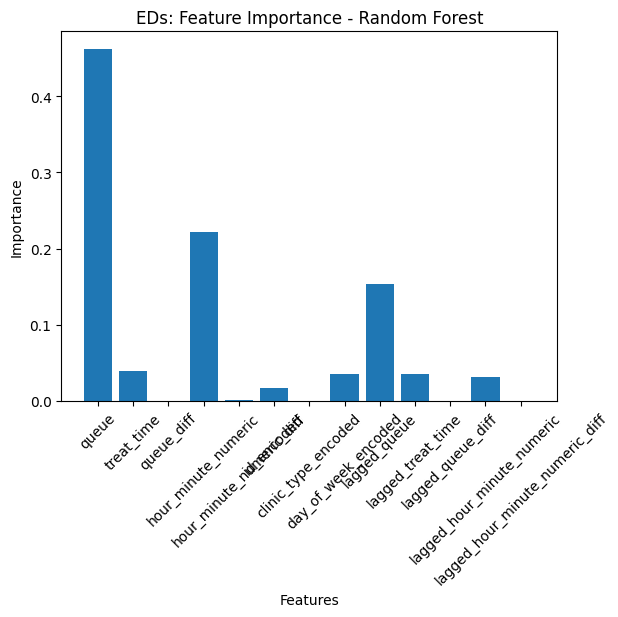

In [98]:
import matplotlib.pyplot as plt

# Extract feature importance for Random Forest (as an example)
rf_importance = models.loc[models['model_name'] == 'Random Forest', 'feature_importance'].values[0]

# Plot feature importance
plt.bar(X.columns, rf_importance)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('EDs: Feature Importance - Random Forest')
plt.xticks(rotation=45)
plt.show()

In [99]:
# Identify the best model based on RMSE
best_model_index = models['rmse'].idxmin()  # Or use another metric, e.g., 'r2' for maximization
best_model_name = models.loc[best_model_index, 'model_name']
best_model = models.loc[best_model_index, 'model']

print(f"Best Model: {best_model_name} with RMSE: {models.loc[best_model_index, 'rmse']}")

Best Model: XGBoost with RMSE: 0.4503025030902543


In [100]:
# Later, you can load the model back for predictions
loaded_model = joblib.load(f'best_model_{best_model_name}.pkl')

In [110]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## **TBC**

In [102]:
# Load the saved model
loaded_model = joblib.load(f'best_model_{best_model_name}.pkl')
print(f"Loaded {best_model_name} successfully.")

Loaded XGBoost successfully.


In [103]:
# Example: Use the loaded model to predict
# Prepare new data for prediction
data = pd.read_csv("test_chs_waittimes.csv")

In [104]:
# Encode 'id' and 'clinic_type'
label_encoder_id = LabelEncoder()
label_encoder_clinic_type = LabelEncoder()

data['id_encoded'] = label_encoder_id.fit_transform(data['id'])
data['clinic_type_encoded'] = label_encoder_clinic_type.fit_transform(data['clinic_type'])

# Drop original categorical columns to avoid redundancy
# data = data[data['id'] == "DICWIC"]
data = data.drop(columns=['id', 'clinic_type'])

# Map days of the week to numeric values
day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

data['day_of_week_encoded'] = data['day_of_week'].map(day_mapping)

data = data.dropna()

# Split data into training and testing sets
# WIC == 1, ED == 0

X = data[data['clinic_type_encoded'] == 0][['queue', 'treat_time', 'queue_diff', 'hour_minute_numeric', 'hour_minute_numeric_diff', 'id_encoded', 'clinic_type_encoded', 'day_of_week_encoded',
                                            'lagged_queue', 'lagged_treat_time', 'lagged_queue_diff', 'lagged_hour_minute_numeric', 'lagged_hour_minute_numeric_diff']]
y = data[data['clinic_type_encoded'] == 0][['wait_time']]

# X = data[data['clinic_type_encoded'] == 1][['queue', 'treat_time', 'queue_diff', 'hour_minute_numeric', 'hour_minute_numeric_diff', 'id_encoded', 'clinic_type_encoded', 'day_of_week_encoded',
#                                            'lagged_queue', 'lagged_treat_time', 'lagged_queue_diff', 'lagged_hour_minute_numeric', 'lagged_hour_minute_numeric_diff']]
# y = data[data['clinic_type_encoded'] == 1][['wait_time']]

# Align indices
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [105]:
# Make predictions with the loaded model
predictions = loaded_model.predict(X)
print("Predictions:", predictions)

Predictions: [2.841847  2.8254905 2.8519123 ... 3.3272629 3.3227751 3.2525766]
